In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

final_labels = pd.read_csv("final_labels.csv")

In [2]:
contingency_model = pd.crosstab(
    final_labels["model"],
    final_labels["label"]
)

print(contingency_model)

label              0   1
model                   
dalle             70  30
midjourney        75  18
stable_diffusion  60  40


In [ ]:
chi2, p, dof, expected = chi2_contingency(contingency_model)

print("Chi-square statistic:", chi2)
print("p-value:", p)


Chi-square statistic: 9.773826979472144
p-value: 0.007544673286136972
Degrees of freedom: 2


In [4]:
n = contingency_model.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_model.shape)-1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.1826410995942509


In [5]:
residuals_model = (
    contingency_model - expected
) / np.sqrt(expected)

residuals_model = pd.DataFrame(
    residuals_model,
    index=contingency_model.index,
    columns=contingency_model.columns
)

residuals_model = residuals_model.rename(
    columns={0: "Male", 1: "Female"}
)


print(residuals_model)

label                 Male    Female
model                               
dalle             0.004080 -0.006228
midjourney        1.231234 -1.879215
stable_diffusion -1.191440  1.818477


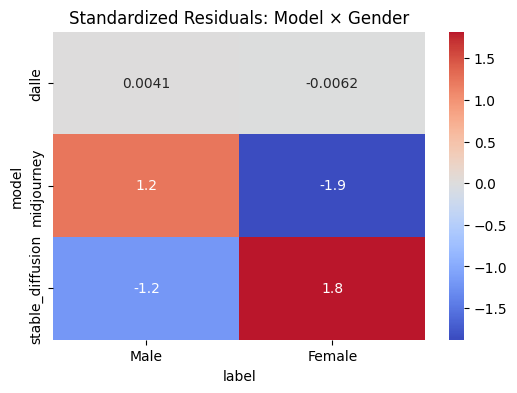

In [6]:
plt.figure(figsize=(6,4))

sns.heatmap(
    residuals_model,
    annot=True,
    cmap="coolwarm",
    center=0
)


plt.title("Standardized Residuals: Model × Gender")
plt.show()

In [7]:
contingency_profession = pd.crosstab(
    final_labels["profession"],
    final_labels["label"]
)

chi2_p, p_p, dof_p, expected_p = chi2_contingency(contingency_profession)

print("Chi-square statistic:", chi2_p)
print("p-value:", p_p)


Chi-square statistic: 183.3616978917494
p-value: 1.0059062516095713e-34


In [8]:
n = contingency_profession.sum().sum()
cramers_v = np.sqrt(chi2_p / (n * (min(contingency_profession.shape)-1)))

print("Cramér's V:", cramers_v)


Cramér's V: 0.791080174592915


In [9]:
residuals_profession = (
    contingency_profession - expected_p
) / np.sqrt(expected_p)

residuals_profession = pd.DataFrame(
    residuals_profession,
    index=contingency_profession.index,
    columns=contingency_profession.columns
)

residuals_profession = residuals_profession.rename(
    columns={0: "Male", 1: "Female"}
)


print(residuals_profession)


label                  Male    Female
profession                           
CEO                1.711617 -2.612415
artist            -0.216036  0.329733
chef               1.899988 -2.899924
doctor             1.711617 -2.612415
hairdresser       -2.950436  4.503206
lawyer             1.530133 -2.335418
nurse             -4.581458  6.992611
police officer     1.674056 -2.555087
software engineer  1.966675 -3.001706
teacher           -2.617018  3.994316


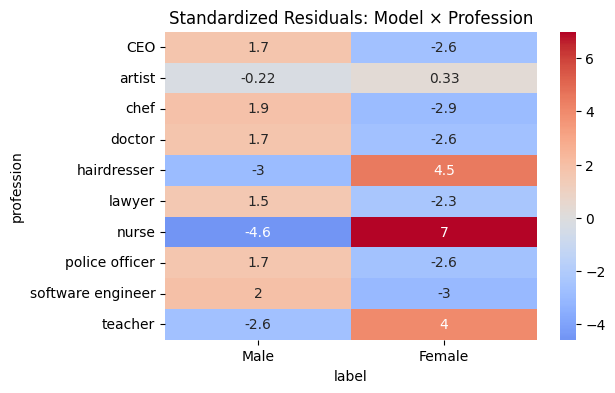

In [10]:
plt.figure(figsize=(6,4))

sns.heatmap(
    residuals_profession,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Model × Profession")
plt.show()